In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [36]:
df = pd.read_csv('Math-Students.csv')
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


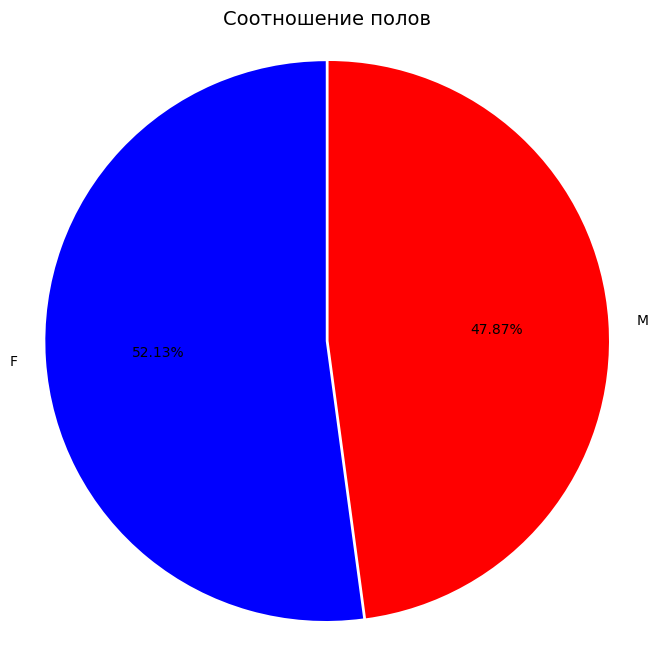

In [37]:
gender_counts = df['sex'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(gender_counts.values, 
        labels=gender_counts.index,
        autopct='%1.2f%%',
        colors=['blue', 'red'],
        startangle=90,
        explode=(0.01, 0)) 

plt.title('Соотношение полов', fontsize=14)
plt.axis('equal')
plt.show()

In [38]:
gender_counts = df['G1'].value_counts()
gender_counts
# plt.figure(figsize=(8, 5))
# bars = plt.bar(gender_counts.index, gender_counts.values, 
#                color=['skyblue', 'lightcoral'], 
#                edgecolor='black', 
#                width=0.6)

G1
10    51
8     45
11    39
7     37
12    35
13    33
9     31
14    30
15    24
6     24
16    22
18     8
17     8
5      7
19     3
4      1
3      1
Name: count, dtype: int64

C:\Users\prosh\AppData\Local\Temp\ipykernel_9172\1053295092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='traveltime', y='G1', data=df, palette='viridis')


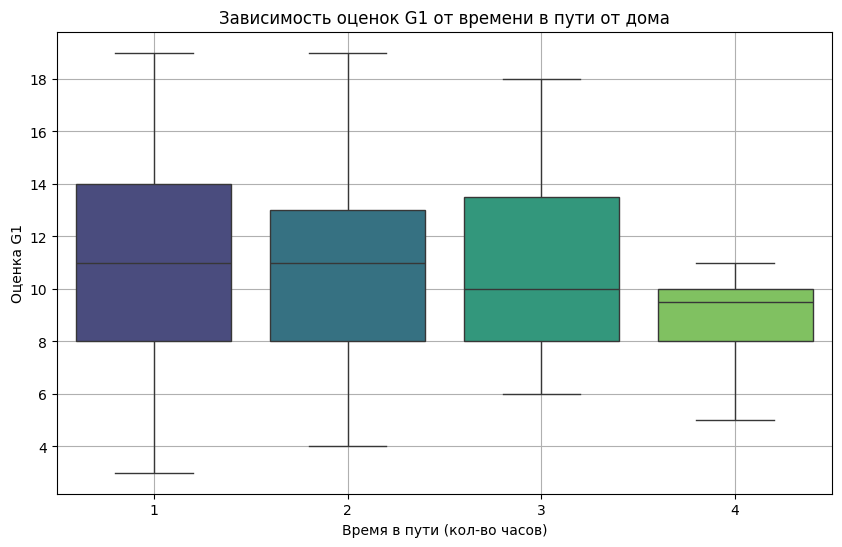

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='traveltime', y='G1', data=df, palette='viridis')
plt.title('Зависимость оценок G1 от времени в пути от дома')
plt.xlabel('Время в пути (кол-во часов)')
plt.ylabel('Оценка G1')
plt.grid(True)
plt.show()

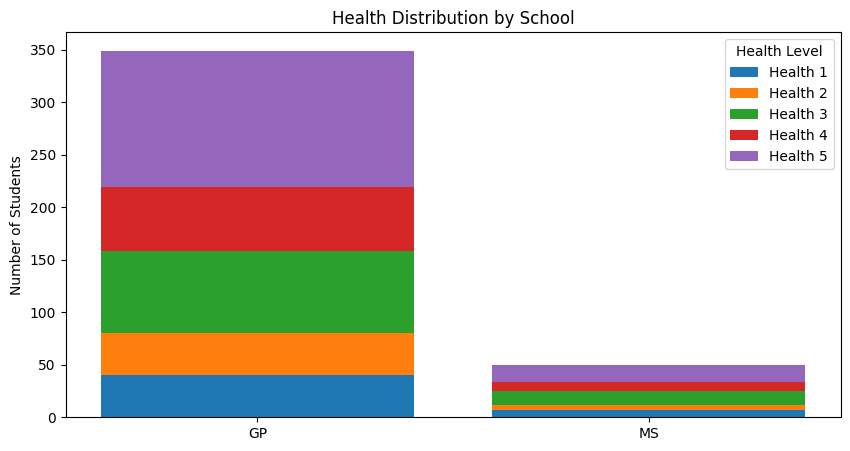

In [40]:
health_by_school = df.groupby(['school', 'health']).size().unstack()

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(health_by_school))

for level in sorted(df['health'].unique()):
    ax.bar(health_by_school.index, 
           health_by_school[level], 
           bottom=bottom,
           label=f'Health {level}')
    bottom += health_by_school[level]

ax.set_title('Health Distribution by School')
ax.set_ylabel('Number of Students')
ax.legend(title='Health Level')
plt.show()

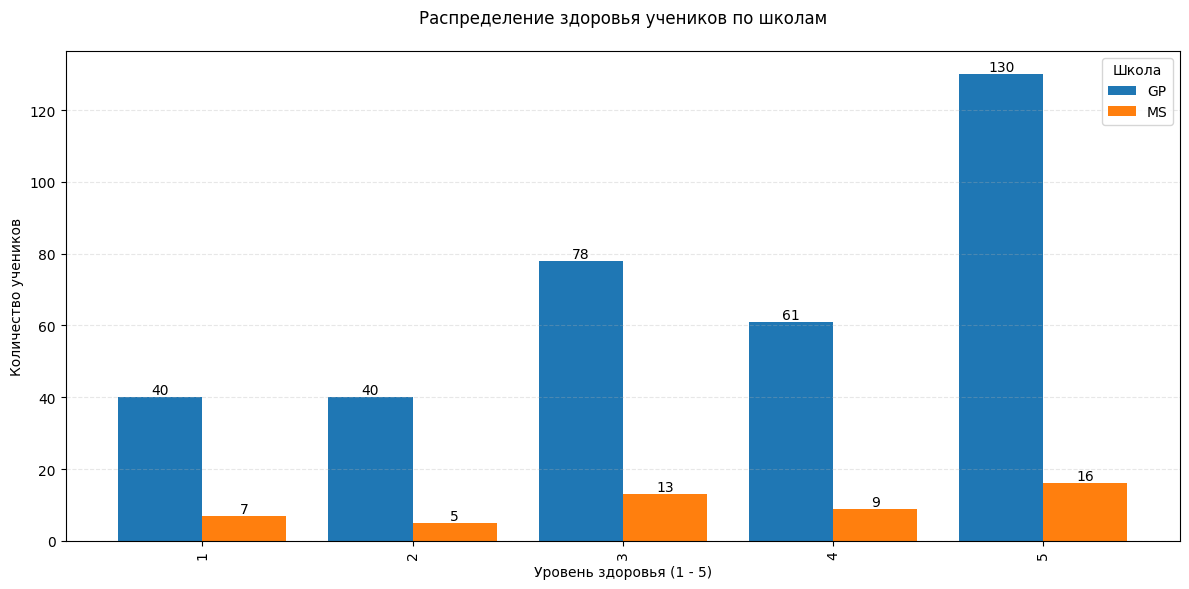

In [55]:


# Группируем данные по уровням здоровья и школам
health_data = df.groupby(['health', 'school']).size().unstack()

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

# Цвета для разных школ
school_colors = {'GP': '#1f77b4', 'MS': '#ff7f0e'}  # Синий и оранжевый

# Строим столбчатую диаграмму
health_data.plot(kind='bar', 
                 color=[school_colors.get(x, '#333333') for x in health_data.columns],
                 ax=ax,
                 width=0.8)

# Настройки графика
ax.set_title('Распределение здоровья учеников по школам', pad=20)
ax.set_xlabel('Уровень здоровья (1 - 5)')
ax.set_ylabel('Количество учеников')
ax.legend(title='Школа')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Добавляем подписи
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height())}", 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 5), 
                   textcoords='offset points')

plt.tight_layout()
plt.show()

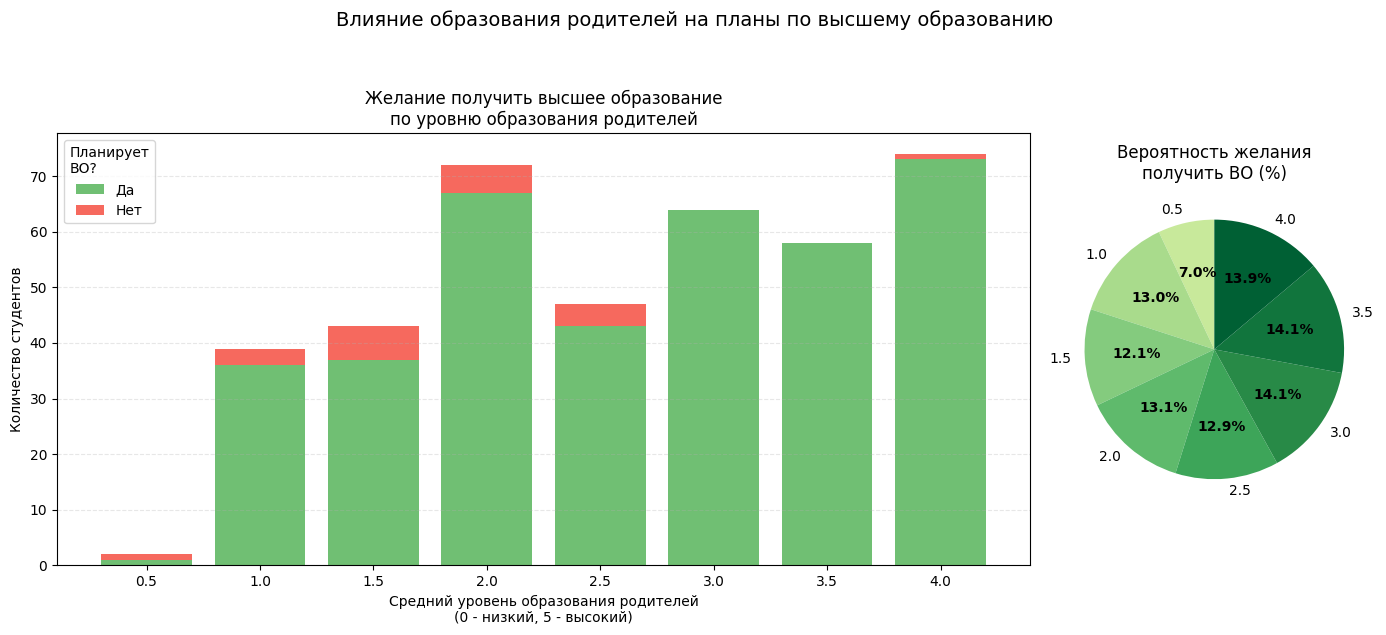

In [42]:
df['parent_edu'] = (df['Medu'] + df['Fedu']) / 2  # Среднее образование родителей
higher_by_edu = df.groupby(['parent_edu', 'higher']).size().unstack()

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})

# 1. Stacked bar plot (количества)
colors = {'yes': '#4caf50', 'no': '#f44336'}  # Зеленый/красный
bottom = np.zeros(len(higher_by_edu))

for response in ['yes', 'no']:
    ax1.bar(higher_by_edu.index.astype(str), 
           higher_by_edu[response], 
           bottom=bottom,
           label='Да' if response == 'yes' else 'Нет',
           color=colors[response],
           alpha=0.8)
    bottom += higher_by_edu[response]

ax1.set_title('Желание получить высшее образование\nпо уровню образования родителей')
ax1.set_xlabel('Средний уровень образования родителей\n(0 - низкий, 5 - высокий)')
ax1.set_ylabel('Количество студентов')
ax1.legend(title='Планирует\nВО?')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 2. Pie chart (процент "да" от общего числа)
yes_percent = df.groupby('parent_edu')['higher'].apply(
    lambda x: (x == 'yes').mean() * 100)

wedges, texts, autotexts = ax2.pie(
    yes_percent,
    labels=yes_percent.index.astype(str),
    autopct='%.1f%%',
    colors=plt.cm.YlGn(np.linspace(0.3, 0.9, len(yes_percent))),
    startangle=90)

ax2.set_title('Вероятность желания\nполучить ВО (%)')
plt.setp(autotexts, size=10, weight='bold')

# Общий заголовок
plt.suptitle('Влияние образования родителей на планы по высшему образованию', 
             y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

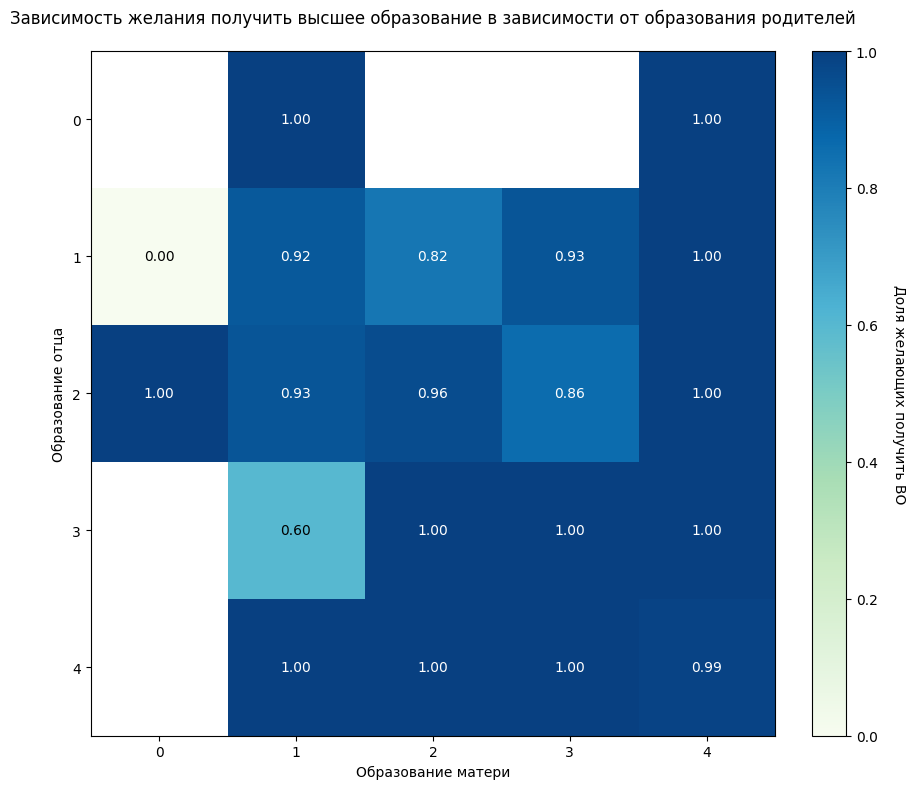

In [53]:
df['higher_num'] = df['higher'].map({'no': 0, 'yes': 1})

# Создаем сводную таблицу для heatmap
heatmap_data = df.pivot_table(
    index='Fedu',  # Образование отца (0-4)
    columns='Medu',  # Образование матери (0-4)
    values='higher_num',  # Доля желающих получить ВО
    aggfunc='mean'  # Среднее значение (процент 1)
)

# Визуализация
plt.figure(figsize=(10, 8))

# Создаем heatmap
im = plt.imshow(heatmap_data, 
               cmap='GnBu',  # Желто-зеленая палитра
               vmin=0, 
               vmax=1)

# Добавляем цветовую шкалу
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Доля желающих получить ВО', rotation=270, labelpad=20)

# Настройка осей
plt.xticks(np.arange(5), labels=range(5))
plt.yticks(np.arange(5), labels=range(5))
plt.xlabel('Образование матери')
plt.ylabel('Образование отца')
plt.title('Зависимость желания получить высшее образование в зависимости от образования родителей', pad=20)

# Добавляем аннотации
for i in range(5):
    for j in range(5):
        value = heatmap_data.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f'{value:.2f}', 
                    ha='center', 
                    va='center',
                    color='black' if value < 0.7 else 'white')

plt.tight_layout()
plt.show()

                mean       std  count
studytime                            
1          10.047619  4.956311    105
2          10.108911  4.198794    202
3          11.400000  4.639504     65
4          11.259259  5.281263     27


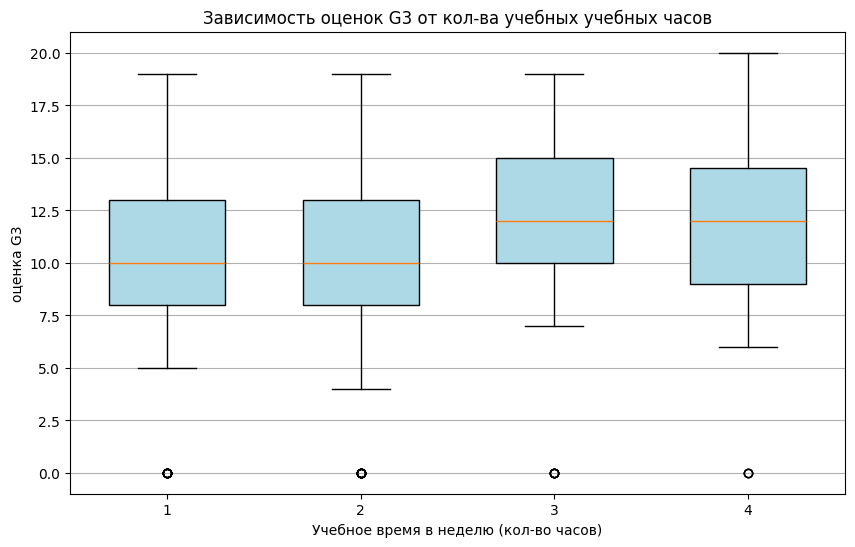

In [54]:
# Группировка данных
study_groups = df.groupby('studytime')['G3'].agg(['mean', 'std', 'count'])
print(study_groups)

plt.figure(figsize=(10, 6))

# Boxplot
boxprops = dict(facecolor='lightblue', edgecolor='black')
plt.boxplot([df[df['studytime']==i]['G3'] for i in sorted(df['studytime'].unique())],
            positions=sorted(df['studytime'].unique()),
            widths=0.6,
            patch_artist=True,
            boxprops=boxprops)


plt.title('Зависимость оценок G3 от кол-ва учебных учебных часов')
plt.xlabel('Учебное время в неделю (кол-во часов)')
plt.ylabel('оценка G3')
plt.grid(axis='y')
plt.show()